In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Imports

import os
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay
)


# Functions



In [ ]:
def preprocess_cicids(df, scaler=None, apply_scaling = True):
    """
    Preprocessing dataset

    Args:
        df: Input dataframe
        scaler: Pre-fitted scaler (for val - test data)
        apply_scaling: Whether to apply scaling (False for Random Forest)

    Returns:
        X: Features (scaled or unscaled)
        y: Binary labels
        scaler: Fitted scaler (or None)
    """

    # Make a copy
    df = df.copy()

    # Clean names - Chops off any spaces, tabs or newline character at the very beginning or the very end of a string
    df.columns = df.columns.str.strip()

    # Handle NaN and Inf
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True) #fixes index

    # Binary encoding: Create new column
    df['binary_label'] = (df['Label'] != 'BENIGN').astype(int) #so attack is positive class 1 and normal is negative class 0

    # Keep only numeric columns, exclude BOTH labels
    feature_cols = [c for c in df.columns
                    if c not in ['Label', 'binary_label']
                    and df[c].dtype in ['int64', 'float64', 'int32', 'float32']]

    # Split X and y
    X = df[feature_cols].values
    y = df['binary_label'].values

    # Optional scaling - (When scaling data, it’s crucial to fit the scaler only on the training data and
                              #then use the same scaler to transform the validation and test sets.)
    if apply_scaling:
        if scaler is None:
            scaler = StandardScaler()  # mean is 0 and standard deviation is 1
            X = scaler.fit_transform(X) #this is used on training data
        else:
            X = scaler.transform(X) # used on test set where you use the exact same mean and deviation used in training

    return X, y, scaler

In [ ]:
def evaluate_model(y_true, y_pred, y_proba = None, model_name = "Model", show_per_class=True):
  """
    Evalutaion on models with metrics and visualization
    Args:
        y_true: True labels
        y_pred: Predicted labels
        y_proba: Predicted probabilities
        model_name: Name of the model
        show_per_class: Whether to show per-class metrics

    Returns:
        acc: Accuracy
        prec: Precision
        rec: Recall
        f1: F1 Score
  """

  print(f"\nEvaluating {model_name}")

  acc = accuracy_score(y_true, y_pred)
  prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average = 'binary')

  print(f"Accuracy: {acc:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"Recall: {rec:.4f}")
  print(f"F1 Score: {f1:.4f}")

  if show_per_class:
        prec_class, rec_class, f1_class, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[0, 1], zero_division=0)

        print(f"\nPer-Class Metrics:")
        print(f"  Class 0 (Normal):")
        print(f"    Precision: {prec_class[0]:.4f}")
        print(f"    Recall:    {rec_class[0]:.4f}")
        print(f"    F1-Score:  {f1_class[0]:.4f}")
        print(f"  Class 1 (Attack):")
        print(f"    Precision: {prec_class[1]:.4f}")
        print(f"    Recall:    {rec_class[1]:.4f}")
        print(f"    F1-Score:  {f1_class[1]:.4f}")


  if y_proba is not None:
    try:
      roc_auc = roc_auc_score(y_true, y_proba)
      pr_auc = average_precision_score(y_true, y_proba)
      print(f"\nAUC Metrics:")
      print(f"ROC-AUC: {roc_auc:.4f}")
      print(f"PR-AUC: {pr_auc:.4f}")
    except ValueError as e:
      print(f"Could not calculate AUC: {e}")

  # Confusion Matrix (with heatmap)
  print(f"\n Confusion Matrix:")
  cm = confusion_matrix(y_true, y_pred)

  # Plot confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 14, 'weight': 'bold'})
  plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
  plt.ylabel('True Label', fontsize=12, fontweight='bold')
  plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
  plt.tight_layout()

  # Save with model name
  safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").lower()
  plt.savefig(f'{safe_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
  plt.show()

  # Detailed classification report
  print(f"\n Detailed Classification Report:")
  print(classification_report(y_true, y_pred,
                                target_names=['Normal (0)', 'Attack (1)'],
                                digits=4))


  return acc, prec, rec, f1

# Import Dataset and Preprocessing



In [ ]:
SAMPLE_PATH = "/content/drive/MyDrive/Machine_Learning/cicids2017_project/cicids2017_sample_30pct.parquet"

df_sample = pd.read_parquet(SAMPLE_PATH)
print(df_sample.shape)
print(df_sample.head())

df_sample.columns = df_sample.columns.str.strip()
print(df_sample.columns.tolist()[:20])  # quick check

(849223, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                443        32046067                   2   
1                 53           66073                   4   
2                 53           60025                   1   
3                 53           47619                   1   
4                 80        99329635                   6   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           74   
1                        4                          176   
2                        1                           56   
3                        1                           44   
4                        7                          320   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                      37   
1                           428                      44   
2                           112                      56   
3                           213    

In [ ]:
# Find columns where every row has the same value and drop them to make training quicker
constant_cols = [col for col in df_sample.columns if df_sample[col].nunique() <= 1]

print(f"Columns to drop: {constant_cols}")

df_sample.drop(columns=constant_cols, inplace=True)

Columns to drop: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [ ]:
print(df_sample.shape)

(849223, 71)


In [ ]:
#Splitting into train-val and train

train_df , test_df = train_test_split(df_sample, test_size=0.2, random_state=42, stratify=df_sample['Label'])
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42, stratify=train_df['Label'])

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(509533, 71)
(169845, 71)
(169845, 71)


In [ ]:
#Preprpocess data

#For models that need scaling (LR, IF, AE)
X_train , y_train, scaler = preprocess_cicids(train_df, apply_scaling = True)
X_val , y_val, _ = preprocess_cicids(val_df, scaler=scaler, apply_scaling = True)
X_test , y_test, _ = preprocess_cicids(test_df, scaler=scaler, apply_scaling = True)


print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Training samples:  {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:      {X_test.shape[0]}")
print(f"\nClass distribution:")
print(f"Benign: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"Attack: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")


Original features: 70
Training samples:  509049
Validation samples: 169646
Test samples:      169679

Class distribution:
Benign: 408923 (80.3%)
Attack: 100126 (19.7%)


In [ ]:
#Features name

feature_cols = [c for c in df_sample.columns if c not in ['Label', 'binary_label'] and train_df[c].dtype in ['int64', 'float64', 'int32', 'float32']]

print(f"Features: {feature_cols}")
print(f"\nNumber of features: {len(feature_cols)}")

Features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Ave

In [ ]:
# Initializing a variable for the results of all models

all_results = []

# Logistic Regression



In [ ]:
# Check each set
print("Training set:")
print(f"  Mean: {np.mean(X_train):.6f}, Std: {np.std(X_train):.6f}")

print("\nValidation set:")
print(f"  Mean: {np.mean(X_val):.6f}, Std: {np.std(X_val):.6f}")

print("\nTest set:")
print(f"  Mean: {np.mean(X_test):.6f}, Std: {np.std(X_test):.6f}")

Training set:
  Mean: 0.000000, Std: 1.000000

Validation set:
  Mean: -0.000875, Std: 0.961944

Test set:
  Mean: 0.000939, Std: 0.941959


In [ ]:
print("Baseline 1: Supervised Learning Logistic Regression")

print("Tuning C on validation set")
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]   # c = 1 / λ regularization
best_c, best_val_f1 = 0.1, 0
val_f1_scores = []

for c in C_values:

  lr_model = LogisticRegression(max_iter=1000, random_state=42, C=c, class_weight='balanced')
  lr_model.fit(X_train, y_train)

  val_pred = lr_model.predict(X_val)
  val_f1 = f1_score(y_val, val_pred)

  val_f1_scores.append(val_f1)
  print(f" C={c}: Val F1={val_f1:.4f}")

  if val_f1 > best_val_f1:
    best_val_f1 = val_f1
    best_c = c

print(f"\nBest C: {best_c} with Val F1: {best_val_f1:.4f}")

Baseline 1: Supervised Learning Logistic Regression
Tuning C on validation set
 C=0.001: Val F1=0.7776
 C=0.01: Val F1=0.7968
 C=0.1: Val F1=0.8053
 C=1.0: Val F1=0.8166
 C=10.0: Val F1=0.8193
 C=100.0: Val F1=0.8195

Best C: 100.0 with Val F1: 0.8195


Training time: 72.37 seconds
Prediction time: 0.04 seconds

Evaluating Logistic Regression
Accuracy: 0.9177
Precision: 0.7169
Recall: 0.9613
F1 Score: 0.8213

Per-Class Metrics:
  Class 0 (Normal):
    Precision: 0.9897
    Recall:    0.9070
    F1-Score:  0.9466
  Class 1 (Attack):
    Precision: 0.7169
    Recall:    0.9613
    F1-Score:  0.8213

AUC Metrics:
ROC-AUC: 0.9798
PR-AUC: 0.9221

 Confusion Matrix:


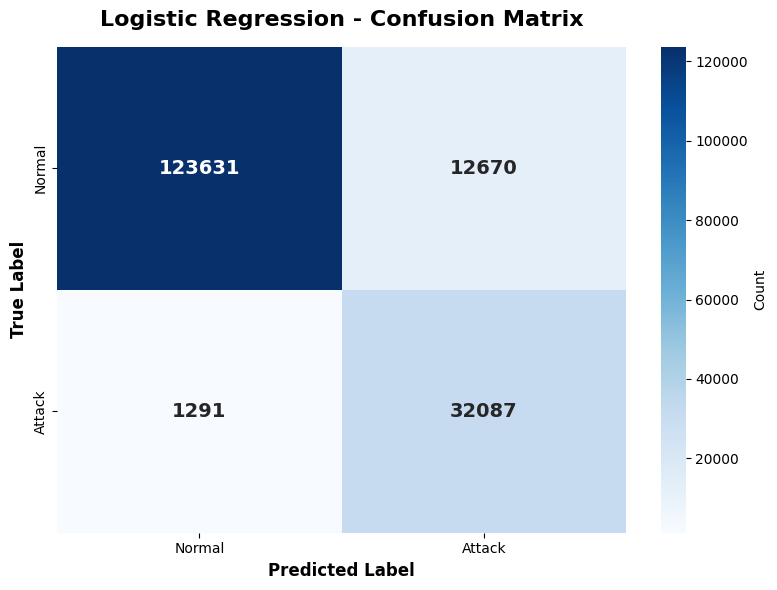


 Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.9897    0.9070    0.9466    136301
  Attack (1)     0.7169    0.9613    0.8213     33378

    accuracy                         0.9177    169679
   macro avg     0.8533    0.9342    0.8839    169679
weighted avg     0.9360    0.9177    0.9219    169679



In [ ]:
#Training with best hyperparameters
best_c = 10.0 #has the best trade-off
start_time = time.time()

lr_model = LogisticRegression(C=best_c, max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

training_time_lr = time.time() - start_time
print(f"Training time: {training_time_lr:.2f} seconds")

pred_start = time.time()

y_test_pred = lr_model.predict(X_test)
y_test_proba = lr_model.predict_proba(X_test)[:, 1]

pred_time = time.time() - pred_start
print(f"Prediction time: {pred_time:.2f} seconds")

lr_results = evaluate_model(y_test, y_test_pred, y_test_proba, "Logistic Regression")

all_results.append({'Model': 'Logistic Regression',
                    'Accuracy': lr_results[0],
                    'Precision': lr_results[1],
                    'Recall': lr_results[2],
                    'F1-Score': lr_results[3],
                    'Training Time (s)': training_time_lr,
                    'Prediction Time (s)': pred_time })

In [ ]:
print(f"Converged: {lr_model.n_iter_}")  # Should be < 1000. If les than 1000 it means that it converged before that.

Converged: [386]


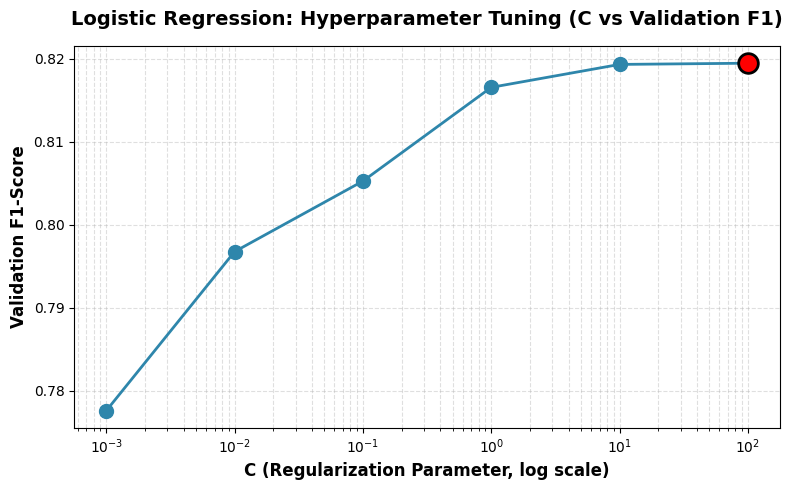

Saved: logreg_C_vs_valF1.png


In [ ]:
#FIRST PLOT (LR) : C vs Validation F1

plt.figure(figsize=(8, 5))
plt.plot(C_values, val_f1_scores, marker='o', markersize=10, linewidth=2, color='#2E86AB')

plt.xscale('log')
plt.xlabel('C (Regularization Parameter, log scale)', fontsize=12, fontweight='bold')
plt.ylabel('Validation F1-Score', fontsize=12, fontweight='bold')
plt.title('Logistic Regression: Hyperparameter Tuning (C vs Validation F1)',
          fontsize=14, fontweight='bold', pad=15)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

# Mark best C
best_idx = val_f1_scores.index(max(val_f1_scores))
plt.scatter(C_values[best_idx], val_f1_scores[best_idx],
           color='red', s=200, zorder=5, edgecolors='black', linewidth=2)

plt.tight_layout()
plt.savefig('logreg_C_vs_valF1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logreg_C_vs_valF1.png")


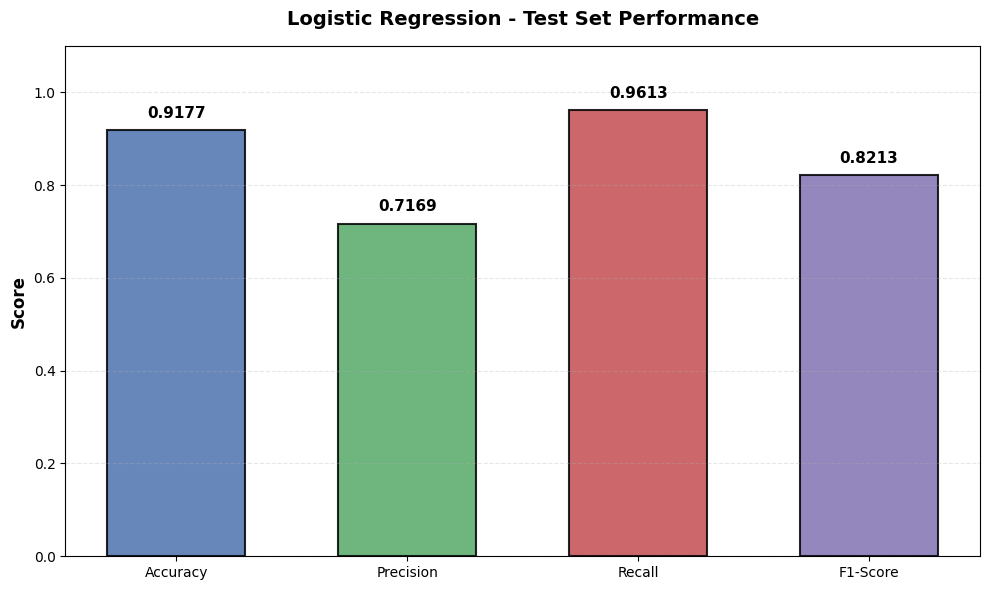

Saved: logreg_test_metrics.png


In [ ]:
#SECOND PLOT (LR): LR Test Metrics Bar Chart
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = lr_results

plt.figure(figsize=(10, 6))
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']
bars = plt.bar(metric_names, metric_values, color=colors, width=0.6,
               edgecolor='black', linewidth=1.5, alpha=0.85)

plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Logistic Regression - Test Set Performance',
          fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f'{height:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('logreg_test_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logreg_test_metrics.png")


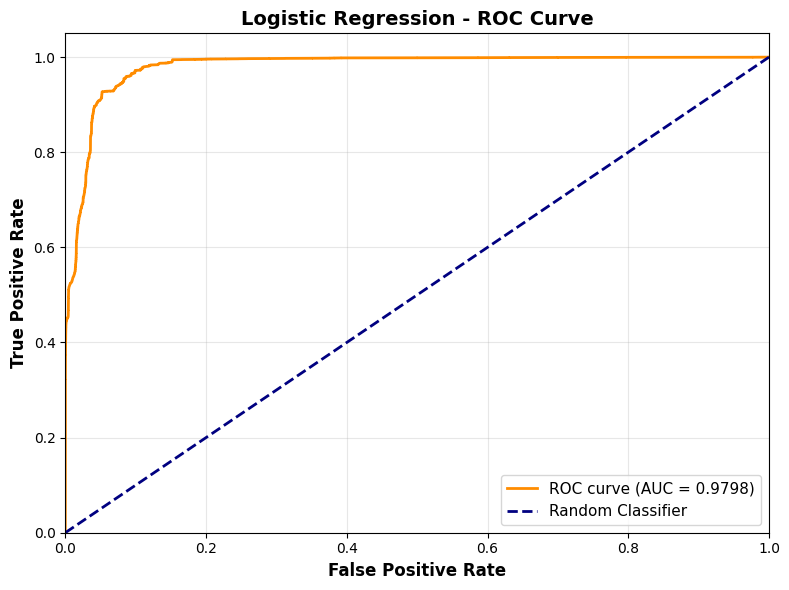

Saved: logreg_roc_curve.png


In [ ]:
#THIRD PLOT (LR): ROC Curve for LR
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba)
roc_auc_lr = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Logistic Regression - ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig('logreg_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logreg_roc_curve.png")

In [ ]:
all_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9177211086816872,
  'Precision': 0.7169157897088724,
  'Recall': 0.9613218287494757,
  'F1-Score': 0.8213220707749408,
  'Training Time (s)': 72.36719608306885,
  'Prediction Time (s)': 0.04415488243103027}]

In [ ]:
#Comment out if want to load the LG results to all_resuts list without rerunning everything
#lr_saved_metrics = {'Model': 'Logistic Regression',
#  'Accuracy': 0.9177211086816872,
#  'Precision': 0.7169157897088724,
#  'Recall': 0.9613218287494757,
#  'F1-Score': 0.8213220707749408,
#  'Training Time (s)': 72.36719608306885,
#  'Prediction Time (s)': 0.04415488243103027}

all_results.append(lr_saved_metrics)

# Random Forest

## *Model for supervised learning*



Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.4min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


Training time: 205.07 seconds


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


Validation F1: 0.9971


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.1s finished



Evaluating Random Forest
Accuracy: 0.9987
Precision: 0.9957
Recall: 0.9978
F1 Score: 0.9967

Per-Class Metrics:
  Class 0 (Normal):
    Precision: 0.9994
    Recall:    0.9989
    F1-Score:  0.9992
  Class 1 (Attack):
    Precision: 0.9957
    Recall:    0.9978
    F1-Score:  0.9967

AUC Metrics:
ROC-AUC: 0.9999
PR-AUC: 0.9994

 Confusion Matrix:


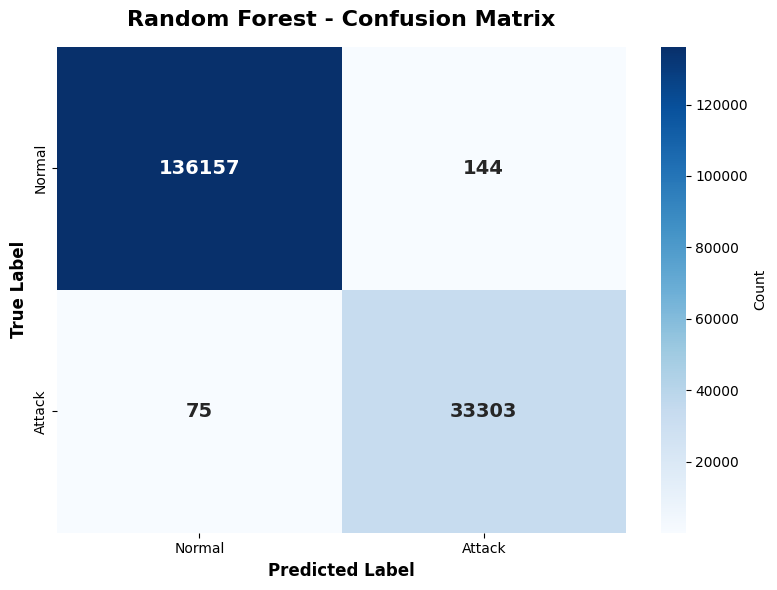


 Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.9994    0.9989    0.9992    136301
  Attack (1)     0.9957    0.9978    0.9967     33378

    accuracy                         0.9987    169679
   macro avg     0.9976    0.9983    0.9980    169679
weighted avg     0.9987    0.9987    0.9987    169679



In [ ]:
#Random Forest

print("Random Forest")

X_train_rf, y_train, _ = preprocess_cicids(train_df, apply_scaling=False)
X_val_rf, y_val, _ = preprocess_cicids(val_df, apply_scaling=False)
X_test_rf, y_test, _ = preprocess_cicids(test_df, apply_scaling=False)

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth = None,
    min_samples_split=5,  # Prevent extreme overfitting
    min_samples_leaf=2,   # Prevent tiny leaves
    class_weight='balanced',
    n_jobs = -1,
    random_state = 42,
    verbose = 1
)

rf_model.fit(X_train_rf, y_train)
training_time_rf = time.time() - start_time
print(f"Training time: {training_time_rf:.2f} seconds")

val_pred = rf_model.predict(X_val_rf)
val_f1 = f1_score(y_val, val_pred)
print(f"Validation F1: {val_f1:.4f}")

pred_start = time.time()
y_test_pred = rf_model.predict(X_test_rf)
y_test_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]
pred_time_rf = time.time() - pred_start

rf_metrics = evaluate_model(y_test, y_test_pred, y_test_prob_rf, "Random Forest")

all_results.append({
    'Model': 'Random Forest',
    'Accuracy': rf_metrics[0],
    'Precision': rf_metrics[1],
    'Recall': rf_metrics[2],
    'F1-Score': rf_metrics[3],
    'Training Time (s)': training_time_rf,
    'Prediction Time (s)': pred_time_rf
})



RANDOM FOREST - CROSS-VALIDATION (5-FOLD)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 15.5min finished



Cross-Validation F1 Scores: [0.99705442 0.99705618 0.99732907 0.99720475 0.99705736]
Mean CV F1: 0.9971 (+/- 0.0002)
Standard Deviation: 0.0001
Min F1: 0.9971
Max F1: 0.9973


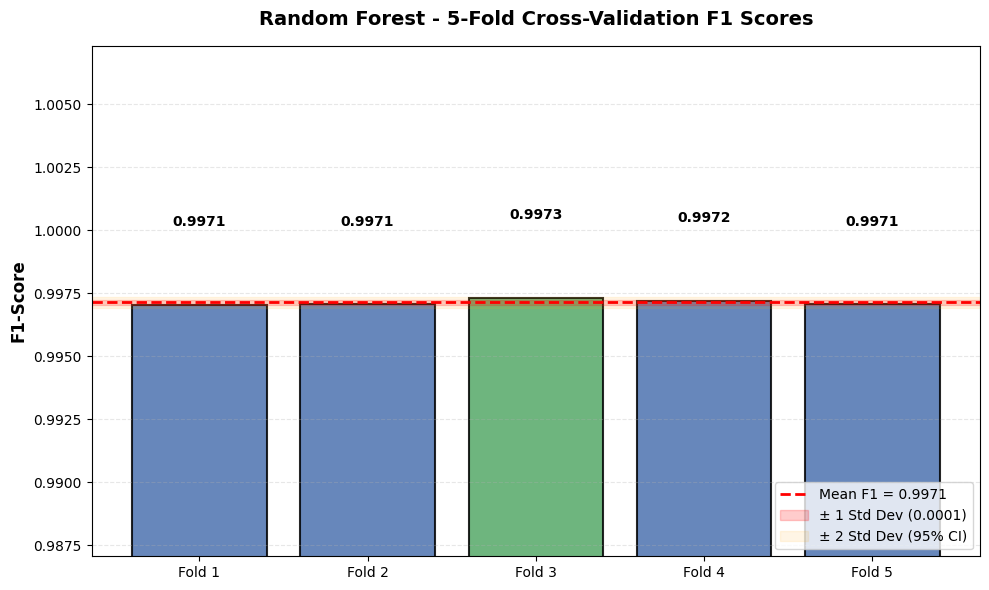

Saved: rf_cross_validation.png


In [ ]:
#FIRST PLOT (RF) - 5FOLD CROSS VALIDATION
from sklearn.model_selection import train_test_split, cross_val_score
print("RANDOM FOREST - CROSS-VALIDATION (5-FOLD)")

cv_scores = cross_val_score(rf_model, X_train_rf, y_train, cv=5,
                            scoring='f1', n_jobs=-1, verbose=1)

print(f"\nCross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Min F1: {cv_scores.min():.4f}")
print(f"Max F1: {cv_scores.max():.4f}")


plt.figure(figsize=(10, 6))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
colors_cv = ['#4c72b0' if i != cv_scores.argmax() else '#55a868' for i in range(len(cv_scores))]

bars = plt.bar(folds, cv_scores, color=colors_cv, edgecolor='black', linewidth=1.5, alpha=0.85)

# Mean line
mean_f1 = cv_scores.mean()
std_f1 = cv_scores.std()
plt.axhline(mean_f1, color='red', linestyle='--', linewidth=2,
           label=f'Mean F1 = {mean_f1:.4f}')

# Standard deviation shaded region (mean ± 1 std)
plt.axhspan(mean_f1 - std_f1, mean_f1 + std_f1,
            alpha=0.2, color='red',
            label=f'± 1 Std Dev ({std_f1:.4f})')

# 95% confidence interval (mean ± 2 std)
plt.axhspan(mean_f1 - 2*std_f1, mean_f1 + 2*std_f1,
            alpha=0.1, color='orange',
            label=f'± 2 Std Dev (95% CI)')

plt.ylim([min(cv_scores.min() - 0.01, mean_f1 - 3*std_f1),
          max(cv_scores.max() + 0.01, mean_f1 + 3*std_f1)])
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('Random Forest - 5-Fold Cross-Validation F1 Scores',
          fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=10, loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.003,
             f'{height:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('rf_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: rf_cross_validation.png")


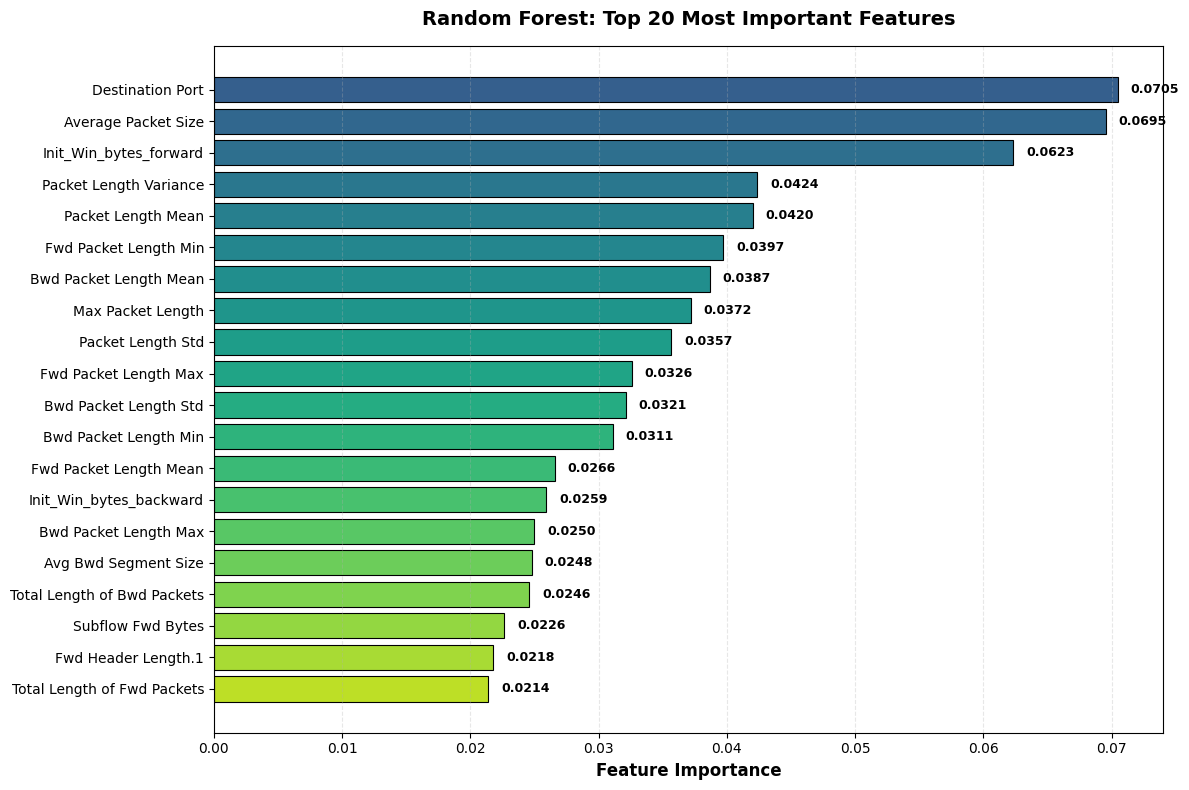

Saved: rf_feature_importance.png


In [ ]:
#SECOND PLOT (RF) : Top 20 Feature Importance
feature_cols_rf = [c for c in df_sample.columns
                   if c not in ['Label', 'binary_label']
                   and df_sample[c].dtype in ['int64','float64','int32','float32']]

top20_idx = np.argsort(rf_model.feature_importances_)[-20:][::-1]
top20_names = [feature_cols_rf[i] for i in top20_idx]
top20_importances = rf_model.feature_importances_[top20_idx]

plt.figure(figsize=(12, 8))
colors_feat = plt.cm.viridis(np.linspace(0.3, 0.9, 20))
bars = plt.barh(range(20), top20_importances, color=colors_feat, edgecolor='black', linewidth=0.8)
plt.yticks(range(20), top20_names, fontsize=10)
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title('Random Forest: Top 20 Most Important Features', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, top20_importances)):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importance.png")


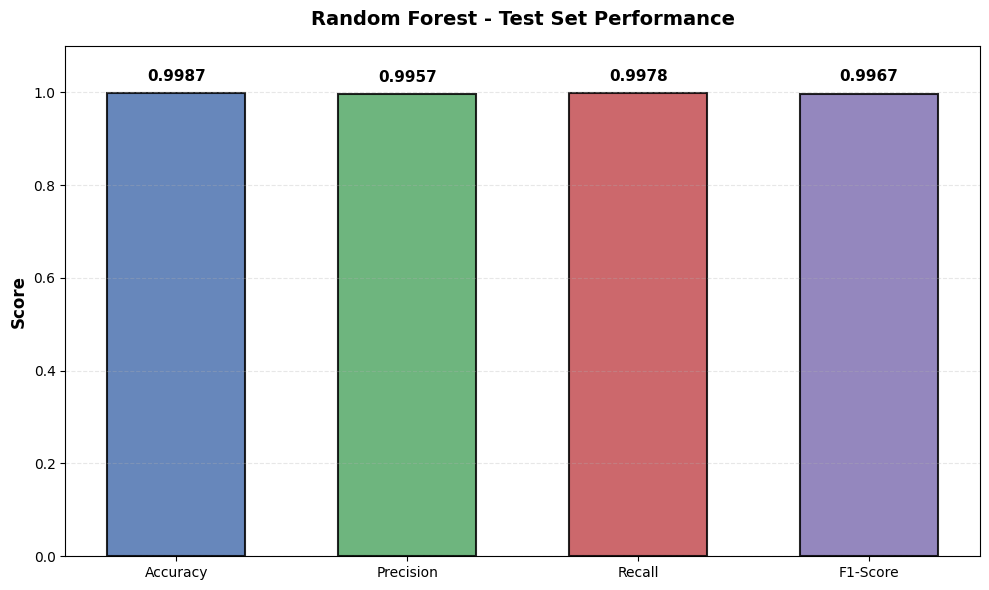

Saved: rf_performance_metrics.png


In [ ]:
#THIRD PLOT (RF): RF Test Metrics
plt.figure(figsize=(10, 6))
metric_names_rf = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_rf = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

bars = plt.bar(metric_names_rf, rf_metrics, color=colors_rf, width=0.6,
               edgecolor='black', linewidth=1.5, alpha=0.85)

plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Random Forest - Test Set Performance', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f'{height:.4f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('rf_performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: rf_performance_metrics.png")

In [ ]:
all_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9177211086816872,
  'Precision': 0.7169157897088724,
  'Recall': 0.9613218287494757,
  'F1-Score': 0.8213220707749408,
  'Training Time (s)': 72.36719608306885,
  'Prediction Time (s)': 0.04415488243103027},
 {'Model': 'Random Forest',
  'Accuracy': 0.9987093276127276,
  'Precision': 0.9956946811373217,
  'Recall': 0.9977530109653064,
  'F1-Score': 0.9967227833894501,
  'Training Time (s)': 205.06956362724304,
  'Prediction Time (s)': 4.733032464981079}]

In [ ]:
#Comment out if want to load the RF results to all_resuts list without rerunning everything
#rf_saved_metrics = {'Model': 'Random Forest',
  #'Accuracy': 0.9987093276127276,
  #'Precision': 0.9956946811373217,
  #'Recall': 0.9977530109653064,
  #'F1-Score': 0.9967227833894501,
  #'Training Time (s)': 205.06956362724304,
  #'Prediction Time (s)': 4.733032464981079}

#all_results.append(rf_saved_metrics)

# Isolation Forest

## *Baseline for unsupervised learning*



Baseline 2: Unsupervised Isolation Forest
Contamination rate: 0.1967
Training time: 22.16 seconds

Tuning threshold on validation set
  Threshold=0.3504: Val F1=0.4592
  Threshold=0.3521: Val F1=0.4707
  Threshold=0.3544: Val F1=0.4829
  Threshold=0.3577: Val F1=0.4948
  Threshold=0.3628: Val F1=0.5068
  Threshold=0.3704: Val F1=0.5187
  Threshold=0.3788: Val F1=0.5303
  Threshold=0.3887: Val F1=0.5435
  Threshold=0.4015: Val F1=0.5500
  Threshold=0.4129: Val F1=0.5482
  Threshold=0.4301: Val F1=0.5453
  Threshold=0.4457: Val F1=0.5238
  Threshold=0.4672: Val F1=0.5073
  Threshold=0.4979: Val F1=0.4938
  Threshold=0.5413: Val F1=0.4594
  Threshold=0.5621: Val F1=0.4024
  Threshold=0.5730: Val F1=0.3360
  Threshold=0.5840: Val F1=0.2633
  Threshold=0.5949: Val F1=0.1833
  Threshold=0.6083: Val F1=0.0959

Best threshold: 0.4015 (Val F1: 0.5500)

Evaluating Isolation Forest (Tuned)
Accuracy: 0.8580
Precision: 0.7252
Recall: 0.4476
F1 Score: 0.5535

Per-Class Metrics:
  Class 0 (Normal):
 

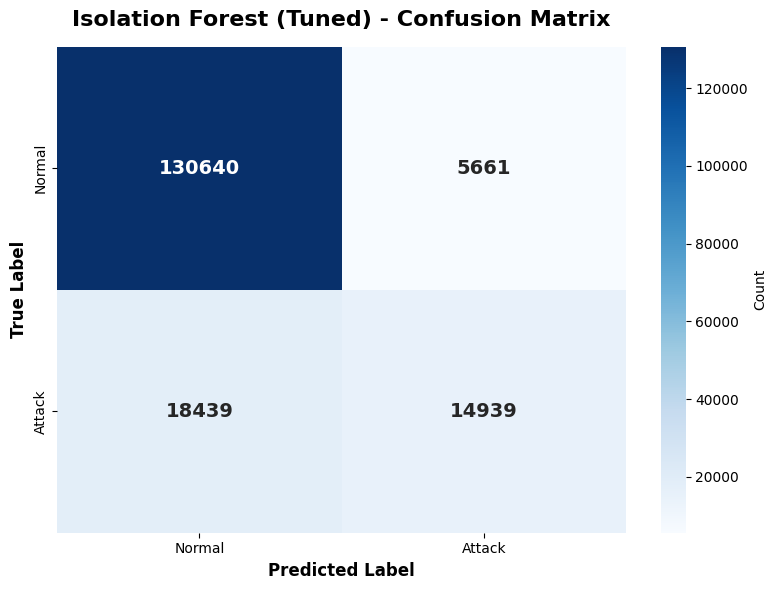


 Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.8763    0.9585    0.9156    136301
  Attack (1)     0.7252    0.4476    0.5535     33378

    accuracy                         0.8580    169679
   macro avg     0.8008    0.7030    0.7345    169679
weighted avg     0.8466    0.8580    0.8443    169679



In [ ]:
#Baseline 2: Unsupervised Isolation Forest

print("Baseline 2: Unsupervised Isolation Forest")

X_train_normal = X_train[y_train == 0]

contamination_rate = y_train.mean()
print(f"Contamination rate: {contamination_rate:.4f}")

start_time = time.time()

if_model = IsolationForest(n_estimators=200, contamination=contamination_rate, random_state=42, n_jobs=-1, max_samples=0.25)
if_model.fit(X_train_normal)

training_time_if = time.time() - start_time
print(f"Training time: {training_time_if:.2f} seconds")

#anomaly scores
val_scores = -if_model.score_samples(X_val)

# Tuning thresholds
print("\nTuning threshold on validation set")
threshold_range = np.percentile(val_scores, np.linspace(80, 99, 20))

best_threshold, best_val_f1 = 0, 0
threshold_f1_pairs = []

for threshold in threshold_range:
    y_val_pred = (val_scores > threshold).astype(int) #convert scores to binary predictions
    val_f1 = f1_score(y_val, y_val_pred)
    threshold_f1_pairs.append((threshold, val_f1))
    print(f"  Threshold={threshold:.4f}: Val F1={val_f1:.4f}")
    if val_f1 > best_val_f1:
        best_threshold, best_val_f1 = threshold, val_f1

print(f"\nBest threshold: {best_threshold:.4f} (Val F1: {best_val_f1:.4f})")

#Use best threshold to test set
pred_start = time.time()
test_scores = -if_model.score_samples(X_test)
y_pred_iso_binary = (test_scores > best_threshold).astype(int)
pred_time_if = time.time() - pred_start

if_metrics = evaluate_model(y_test, y_pred_iso_binary, test_scores, "Isolation Forest (Tuned)")
all_results.append({
    'Model': 'Isolation Forest',
    'Accuracy': if_metrics[0], 'Precision': if_metrics[1],
    'Recall': if_metrics[2], 'F1-Score': if_metrics[3],
    'Training Time (s) ': training_time_if, 'Prediction Time (s)': pred_time_if
})



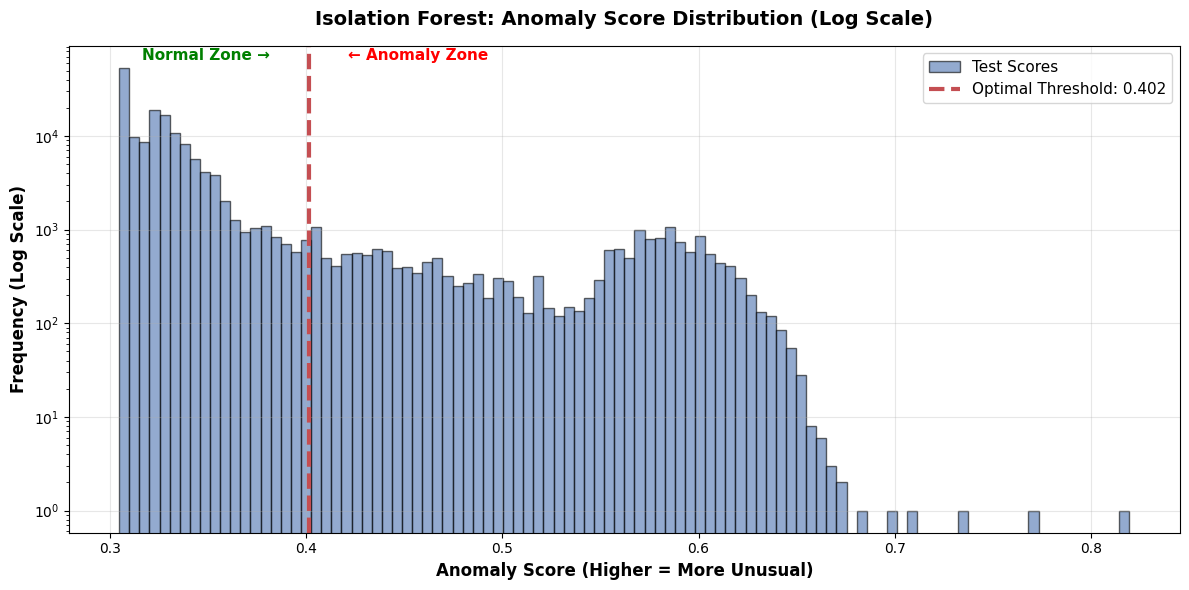

Saved: if_anomaly_score_distribution_log.png


In [ ]:
#FIRST PLOT (IF) - Anomaly Score Distribution
plt.figure(figsize=(12, 6))

# Use log scale for better visualization
plt.hist(test_scores, bins=100, color='#4c72b0', alpha=0.6,
         edgecolor='black', label='Test Scores', log=True)

plt.axvline(best_threshold, color='#c44e52', linestyle='--', linewidth=3,
            label=f'Optimal Threshold: {best_threshold:.3f}')

plt.xlabel('Anomaly Score (Higher = More Unusual)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (Log Scale)', fontsize=12, fontweight='bold')
plt.title('Isolation Forest: Anomaly Score Distribution (Log Scale)',
          fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Add zones
y_pos = plt.ylim()[1] * 0.7
plt.text(best_threshold - 0.02, y_pos, 'Normal Zone →',
         ha='right', fontweight='bold', fontsize=11, color='green')
plt.text(best_threshold + 0.02, y_pos, '← Anomaly Zone',
         ha='left', fontweight='bold', fontsize=11, color='red')

plt.tight_layout()
plt.savefig('if_anomaly_score_distribution_log.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: if_anomaly_score_distribution_log.png")

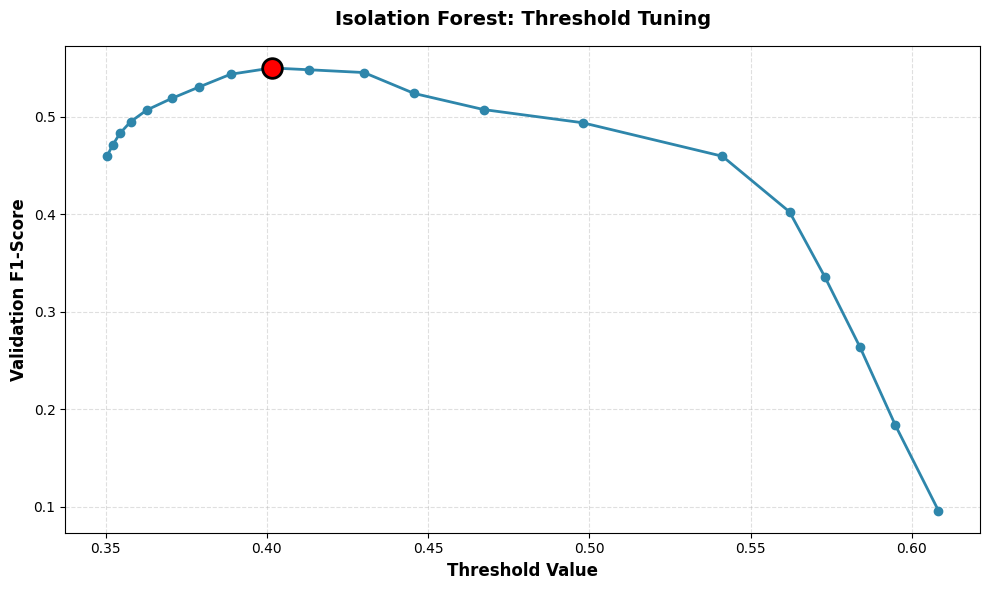

Saved: if_threshold_tuning.png


In [ ]:
#SECOND PLOT (IF): Threshold vs F1 Score
thresholds_plot = [t[0] for t in threshold_f1_pairs]
f1_scores_plot = [t[1] for t in threshold_f1_pairs]

plt.figure(figsize=(10, 6))
plt.plot(thresholds_plot, f1_scores_plot, marker='o', markersize=6, linewidth=2, color='#2E86AB')
plt.xlabel('Threshold Value', fontsize=12, fontweight='bold')
plt.ylabel('Validation F1-Score', fontsize=12, fontweight='bold')
plt.title('Isolation Forest: Threshold Tuning', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.4)

# Mark best threshold
best_idx_if = f1_scores_plot.index(max(f1_scores_plot))
plt.scatter(thresholds_plot[best_idx_if], f1_scores_plot[best_idx_if],
           color='red', s=200, zorder=5, edgecolors='black', linewidth=2)

plt.tight_layout()
plt.savefig('if_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: if_threshold_tuning.png")


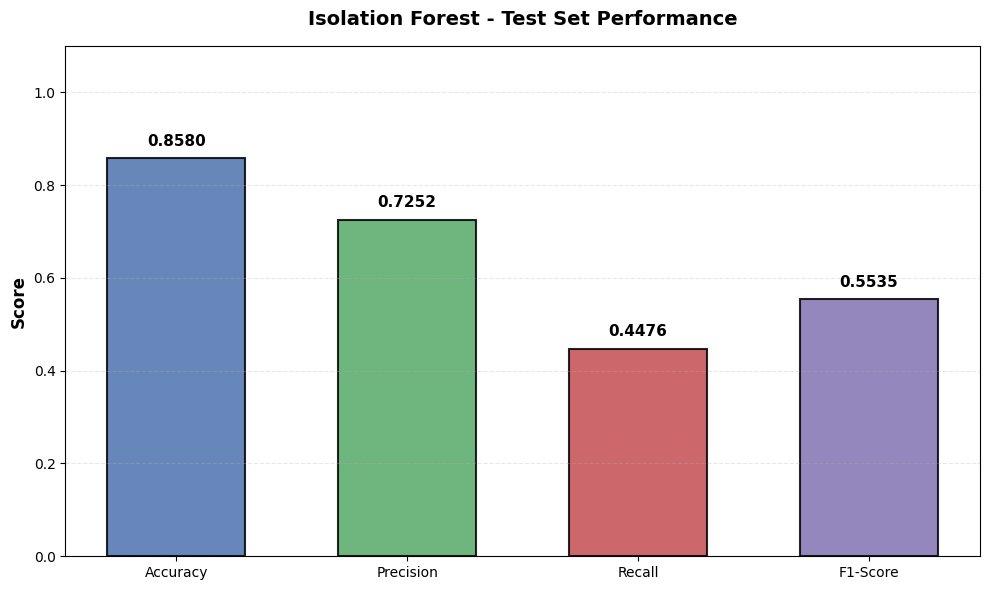

Saved: if_test_metrics.png


In [ ]:
#THIRD PLOT (IF): IF Test Metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [if_metrics[0], if_metrics[1], if_metrics[2], if_metrics[3]]

plt.figure(figsize=(10, 6))
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']
bars = plt.bar(metric_names, metric_values, color=colors, width=0.6,
               edgecolor='black', linewidth=1.5, alpha=0.85)

plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Isolation Forest - Test Set Performance', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f'{height:.4f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('if_test_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: if_test_metrics.png")

In [ ]:
all_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9177211086816872,
  'Precision': 0.7169157897088724,
  'Recall': 0.9613218287494757,
  'F1-Score': 0.8213220707749408,
  'Training Time (s)': 72.36719608306885,
  'Prediction Time (s)': 0.04415488243103027},
 {'Model': 'Random Forest',
  'Accuracy': 0.9987093276127276,
  'Precision': 0.9956946811373217,
  'Recall': 0.9977530109653064,
  'F1-Score': 0.9967227833894501,
  'Training Time (s)': 205.06956362724304,
  'Prediction Time (s)': 4.733032464981079},
 {'Model': 'Isolation Forest',
  'Accuracy': 0.8579671025878276,
  'Precision': 0.7251941747572815,
  'Recall': 0.44757025585715143,
  'F1-Score': 0.5535218051798881,
  'Training Time (s) ': 22.16296100616455,
  'Prediction Time (s)': 5.954294681549072}]

In [ ]:
#Comment out if want to load the IF results to all_resuts list without rerunning everything
#IF_saved_metrics = {'Model':'Isolation Forest',
  #'Accuracy': 0.8579671025878276,
  #'Precision': 0.7251941747572815,
  #'Recall': 0.44757025585715143,
  #'F1-Score': 0.5535218051798881,
  #'Training Time (s)': 22.16296100616455,
  #'Prediction Time (s)': 5.954294681549072}

#all_results.append(IF_saved_metrics)

# Functions for Autoencoder



In [ ]:
class Autoencoder(nn.Module):
  def __init__(self,input_dim, encoding_dim=16):
    super(Autoencoder, self).__init__()

    #Encoder
    self.encoder = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, encoding_dim),
        nn.ReLU()
    )

    #Decoder
    self.decoder = nn.Sequential(
        nn.Linear(encoding_dim, 64),
        nn.ReLU(),
        nn.Linear(64, input_dim)
    )

  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

In [ ]:
def train_autoencoder(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=10):
    """
    Train autoencoder with validation and early stopping.

    Αrgs:
        model (torch.nn.Module): The autoencoder model.
        train_loader (torch.utils.data.DataLoader): DataLoader for training data.
        val_loader (torch.utils.data.DataLoader): DataLoader for validation data.
        criterion (torch.nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Optimizer.
        num_epochs (int): Number of training epochs.
        device (torch.device): Device (CPU or GPU).
        patience (int): Patience for early stopping.

    Returns:
        train_losses (list): List of training losses.
        val_losses (list): List of validation losses.
        best_model_state (dict): State dictionary of the best model.
    """

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            # Forward pass
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y) #batch_x = batch_y

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Print progress
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train Loss: {avg_train_loss:.6f}, '
                  f'Val Loss: {avg_val_loss:.6f}')

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Save best model
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                # Load best model
                model.load_state_dict(best_model_state)
                break

    return train_losses, val_losses, best_model_state


# Autoencoder


In [ ]:
#AutoEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_dim = X_train.shape[1]

# Prepare normal training data (benign only)
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]


print(f"\nInput features:            {input_dim}")
print(f"\nNormal training samples:   {len(X_train_normal)}")
print(f"Normal validation samples: {len(X_val_normal)}")


print("HYPERPARAMETER TUNING FOR ENCODINF_DIM")

encoding_dims = [
    max(4, input_dim // 8),   # Very compressed (8)
    max(8, input_dim // 4),   # Moderately compressed (17)
    max(16, input_dim // 2),  # Lightly compressed (35)
]

learning_rate = 0.001
num_epochs = 50

best_enc_dim = encoding_dims[1]
best_val_loss = float('inf')
tuning_results = []

print(f"\nTesting encoding dimensions: {encoding_dims}")
print("(Based on input features: {})".format(input_dim))
print("(Lower = more compression, Higher = less compression)\n")

for enc_dim in encoding_dims:
    print(f"Testing encoding_dim={enc_dim} (compression ratio: {enc_dim}/{input_dim} = {enc_dim/input_dim:.1%})")

    # Create data loaders
    X_train_tensor = torch.FloatTensor(X_train_normal).to(device)
    X_val_tensor = torch.FloatTensor(X_val_normal).to(device)

    train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Initialize model
    model_temp = Autoencoder(input_dim, enc_dim).to(device)
    criterion_temp = nn.MSELoss()
    optimizer_temp = optim.Adam(model_temp.parameters(), lr=learning_rate)

    # Train
    train_losses, val_losses, best_model_state = train_autoencoder(
        model_temp, train_loader, val_loader,
        criterion_temp, optimizer_temp, num_epochs, device, patience=10
    )

    final_val_loss = min(val_losses)
    print(f"Final Val Loss: {final_val_loss:.6f}\n")

    tuning_results.append({
        'encoding_dim': enc_dim,
        'compression_ratio': f"{enc_dim}/{input_dim}",
        'val_loss': final_val_loss
    })

    if final_val_loss < best_val_loss:
        best_val_loss = final_val_loss
        best_enc_dim = enc_dim


print("HYPERPARAMETER TUNING RESULTS")

tuning_df = pd.DataFrame(tuning_results).sort_values('val_loss')
print(tuning_df.to_string(index=False))

print(f"\n✓ Best encoding_dim: {best_enc_dim} (Val Loss: {best_val_loss:.6f})")
print(f"  Compression ratio: {best_enc_dim}/{input_dim} = {best_enc_dim/input_dim:.1%}")


Using device: cuda

Input features:            70

Normal training samples:   408923
Normal validation samples: 136297
HYPERPARAMETER TUNING FOR ENCODINF_DIM

Testing encoding dimensions: [8, 17, 35]
(Based on input features: 70)
(Lower = more compression, Higher = less compression)

Testing encoding_dim=8 (compression ratio: 8/70 = 11.4%)
Epoch [5/50], Train Loss: 0.096368, Val Loss: 0.042607
Epoch [10/50], Train Loss: 0.070294, Val Loss: 0.031381
Epoch [15/50], Train Loss: 0.038745, Val Loss: 0.025668
Epoch [20/50], Train Loss: 0.042271, Val Loss: 0.024859
Epoch [25/50], Train Loss: 0.035663, Val Loss: 0.026789
Epoch [30/50], Train Loss: 0.030276, Val Loss: 0.032508
Epoch [35/50], Train Loss: 0.028998, Val Loss: 0.028362

Early stopping at epoch 36
Final Val Loss: 0.018573

Testing encoding_dim=17 (compression ratio: 17/70 = 24.3%)
Epoch [5/50], Train Loss: 0.076491, Val Loss: 0.022552
Epoch [10/50], Train Loss: 0.062630, Val Loss: 0.023877
Epoch [15/50], Train Loss: 0.038789, Val Lo

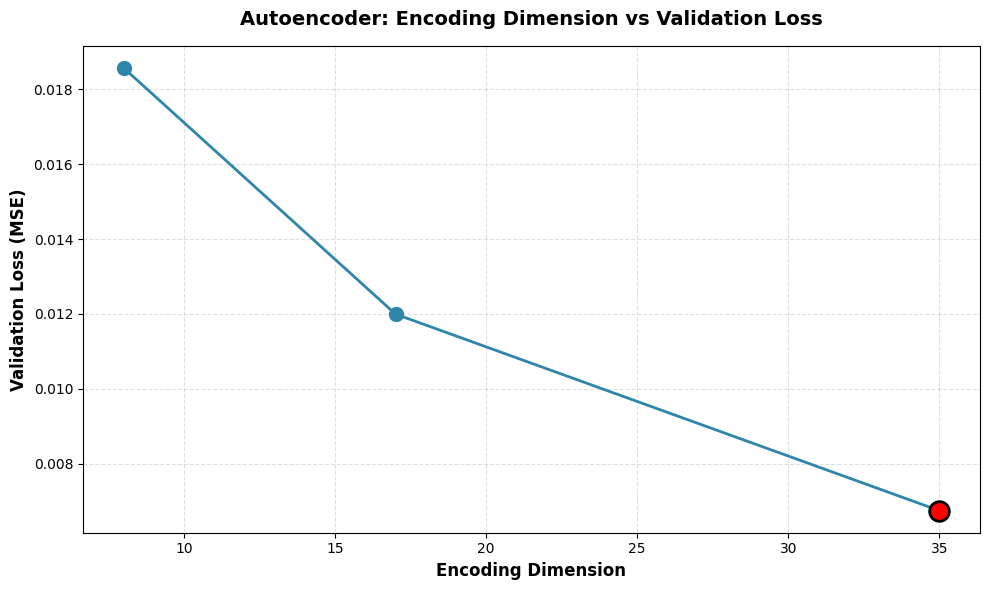

Saved: ae_encoding_dim_tuning.png


In [ ]:
#FIRST PLOT (AE): Encoding Dimension vs Validation Loss
plt.figure(figsize=(10, 6))
enc_dims_plot = [r['encoding_dim'] for r in tuning_results]
val_losses_plot = [r['val_loss'] for r in tuning_results]

plt.plot(enc_dims_plot, val_losses_plot, marker='o', markersize=10, linewidth=2, color='#2E86AB')
plt.xlabel('Encoding Dimension', fontsize=12, fontweight='bold')
plt.ylabel('Validation Loss (MSE)', fontsize=12, fontweight='bold')
plt.title('Autoencoder: Encoding Dimension vs Validation Loss',
          fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.4)

# Mark best
best_idx_ae = val_losses_plot.index(min(val_losses_plot))
plt.scatter(enc_dims_plot[best_idx_ae], val_losses_plot[best_idx_ae],
           color='red', s=200, zorder=5, edgecolors='black', linewidth=2)


plt.tight_layout()
plt.savefig('ae_encoding_dim_tuning.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ae_encoding_dim_tuning.png")

TRAINING FINAL AUTOENCODER WITH BEST HYPERPARAMETERS

Autoencoder Architecture:
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=70, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=35, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=35, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=70, bias=True)
  )
)

Input dimension:    70
Encoding dimension: 35
Compression ratio:  50.0%
Epoch [5/50], Train Loss: 0.075301, Val Loss: 0.090803
Epoch [10/50], Train Loss: 0.060123, Val Loss: 0.025241
Epoch [15/50], Train Loss: 0.053568, Val Loss: 0.009189
Epoch [20/50], Train Loss: 0.028318, Val Loss: 0.005722
Epoch [25/50], Train Loss: 0.039227, Val Loss: 0.017109
Epoch [30/50], Train Loss: 0.014949, Val Loss: 0.020617
Epoch [35/50], Train Loss: 0.015998, Val Loss: 0.004469

Early stopping at epoch 38

Total training time: 307.21 seconds

Final Training Loss:   0.0262

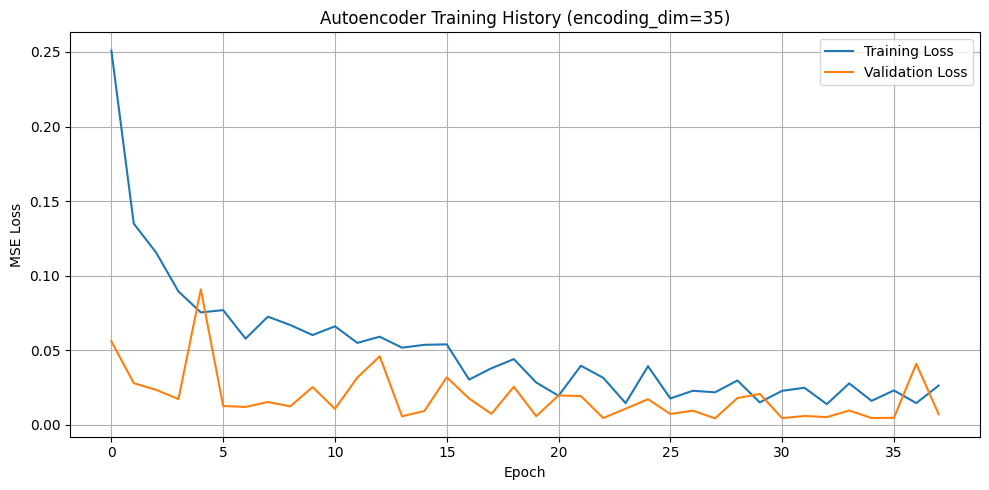

In [ ]:
# Train final autoencoder with best hyperparameters
print("TRAINING FINAL AUTOENCODER WITH BEST HYPERPARAMETERS")

# Create data loaders
X_train_tensor = torch.FloatTensor(X_train_normal).to(device)
X_val_tensor = torch.FloatTensor(X_val_normal).to(device)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# Initialize final model
final_model = Autoencoder(input_dim, best_enc_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(final_model.parameters(), lr=learning_rate)

print("\nAutoencoder Architecture:")
print(final_model)
print(f"\nInput dimension:    {input_dim}")
print(f"Encoding dimension: {best_enc_dim}")
print(f"Compression ratio:  {best_enc_dim/input_dim:.1%}")

# Train final model
start_time = time.time()
train_losses, val_losses, _ = train_autoencoder(
    final_model, train_loader, val_loader,
    criterion, optimizer, num_epochs, device, patience=10
)
training_time_ae = time.time() - start_time
print(f"\nTotal training time: {training_time_ae:.2f} seconds")

print(f"\nFinal Training Loss:   {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Best Validation Loss:  {min(val_losses):.6f}")

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Autoencoder Training History (encoding_dim={best_enc_dim})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


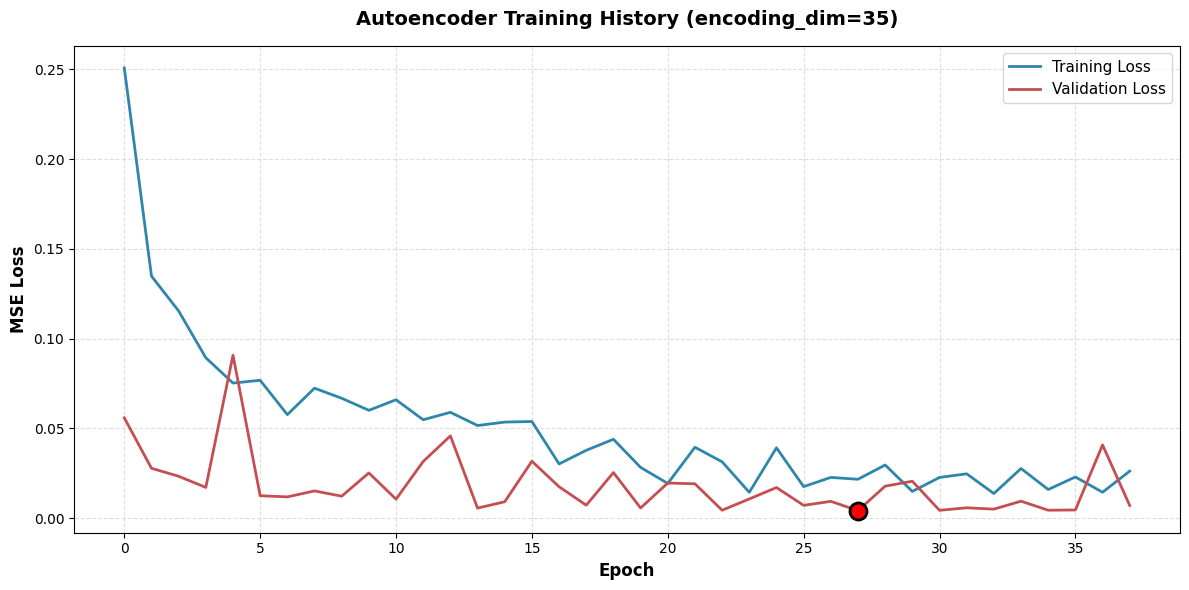

Saved: ae_training_history.png


In [ ]:
#SECOND PLOT (AE) : Training vs Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2, color='#2E86AB')
plt.plot(val_losses, label='Validation Loss', linewidth=2, color='#c44e52')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('MSE Loss', fontsize=12, fontweight='bold')
plt.title(f'Autoencoder Training History (encoding_dim={best_enc_dim})',
          fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

# Mark best validation loss
best_epoch = val_losses.index(min(val_losses))
plt.scatter(best_epoch, val_losses[best_epoch], color='red', s=150,
           zorder=5, edgecolors='black', linewidth=2)


plt.tight_layout()
plt.savefig('ae_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ae_training_history.png")


Generating predictions on test set...

Tuning reconstruction error threshold on validation set...

Threshold candidates (based on normal samples' error distribution):
  90th percentile: Threshold=0.002578, Val F1=0.5152
  95th percentile: Threshold=0.006034, Val F1=0.5521
  97th percentile: Threshold=0.010464, Val F1=0.5760
  99th percentile: Threshold=0.026560, Val F1=0.5876

Best threshold: 0.026560 (Val F1: 0.5876)
Prediction time: 0.5339 seconds

Reconstruction Error Statistics:
  Val (normal only) - Mean: 0.007081, Std: 0.938232
  Test (all samples) - Mean: 0.031261, Std: 0.827041

Evaluating Autoencoder (PyTorch)
Accuracy: 0.8811
Precision: 0.9121
Recall: 0.4375
F1 Score: 0.5913

Per-Class Metrics:
  Class 0 (Normal):
    Precision: 0.8778
    Recall:    0.9897
    F1-Score:  0.9304
  Class 1 (Attack):
    Precision: 0.9121
    Recall:    0.4375
    F1-Score:  0.5913

AUC Metrics:
ROC-AUC: 0.8150
PR-AUC: 0.6407

 Confusion Matrix:


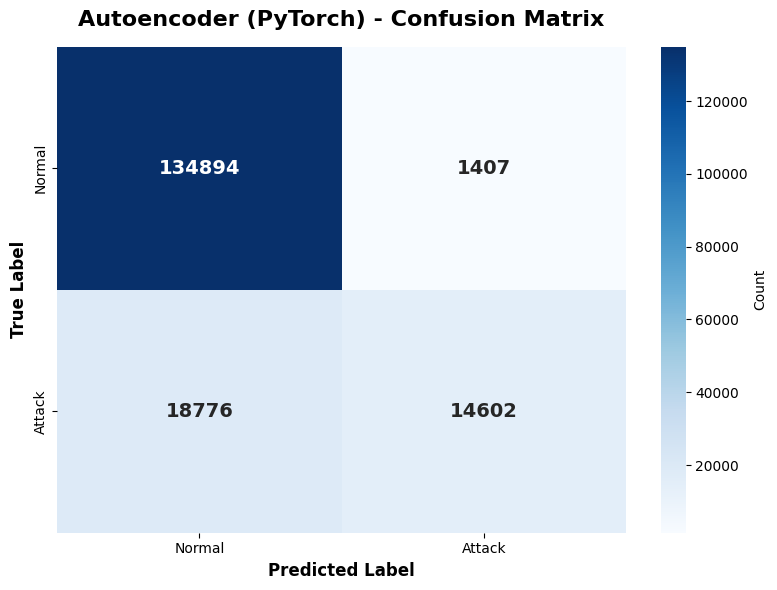


 Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.8778    0.9897    0.9304    136301
  Attack (1)     0.9121    0.4375    0.5913     33378

    accuracy                         0.8811    169679
   macro avg     0.8950    0.7136    0.7609    169679
weighted avg     0.8846    0.8811    0.8637    169679



In [ ]:
# Predict and evaluate
print("\nGenerating predictions on test set...")
pred_start = time.time()

final_model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    X_test_reconstructed = final_model(X_test_tensor).cpu().numpy()

    X_val_reconstructed = final_model(X_val_tensor).cpu().numpy()

# Calculate reconstruction errors
reconstruction_errors_test = np.mean(
    np.square(X_test - X_test_reconstructed), axis=1
)
reconstruction_errors_val_normal = np.mean(
    np.square(X_val_normal - X_val_reconstructed), axis=1
)

# Tune threshold on validation set
print("\nTuning reconstruction error threshold on validation set...")

# Calculate reconstruction errors for FULL validation set
with torch.no_grad():
    X_val_tensor_full = torch.FloatTensor(X_val).to(device)
    X_val_reconstructed_full = final_model(X_val_tensor_full).cpu().numpy()

val_errors_full = np.mean(
    np.square(X_val - X_val_reconstructed_full), axis=1
)

# Use percentiles of NORMAL samples to define threshold candidates
threshold_percentiles = [90, 95, 97, 99]
best_ae_threshold, best_ae_val_f1 = 0, 0
threshold_f1_ae = []

print("\nThreshold candidates (based on normal samples' error distribution):")
for percentile in threshold_percentiles:
    threshold = np.percentile(reconstruction_errors_val_normal, percentile)
    y_val_pred_ae = (val_errors_full > threshold).astype(int)
    val_f1_ae = f1_score(y_val, y_val_pred_ae)
    threshold_f1_ae.append((percentile, threshold, val_f1_ae))
    print(f"  {percentile}th percentile: Threshold={threshold:.6f}, Val F1={val_f1_ae:.4f}")

    if val_f1_ae > best_ae_val_f1:
        best_ae_threshold = threshold
        best_ae_val_f1 = val_f1_ae

print(f"\nBest threshold: {best_ae_threshold:.6f} (Val F1: {best_ae_val_f1:.4f})")

# Apply best threshold to test set
y_pred_ae = (reconstruction_errors_test > best_ae_threshold).astype(int)

pred_time_ae = time.time() - pred_start
print(f"Prediction time: {pred_time_ae:.4f} seconds")

print(f"\nReconstruction Error Statistics:")
print(f"  Val (normal only) - Mean: {reconstruction_errors_val_normal.mean():.6f}, Std: {reconstruction_errors_val_normal.std():.6f}")
print(f"  Test (all samples) - Mean: {reconstruction_errors_test.mean():.6f}, Std: {reconstruction_errors_test.std():.6f}")

# Evaluate
ae_metrics = evaluate_model(
    y_test, y_pred_ae, reconstruction_errors_test, "Autoencoder (PyTorch)"
)
all_results.append({
    'Model': 'Autoencoder',
    'Accuracy': ae_metrics[0],
    'Precision': ae_metrics[1],
    'Recall': ae_metrics[2],
    'F1-Score': ae_metrics[3],
    'Training Time (s)': training_time_ae,
    'Prediction Time (s)': pred_time_ae
})

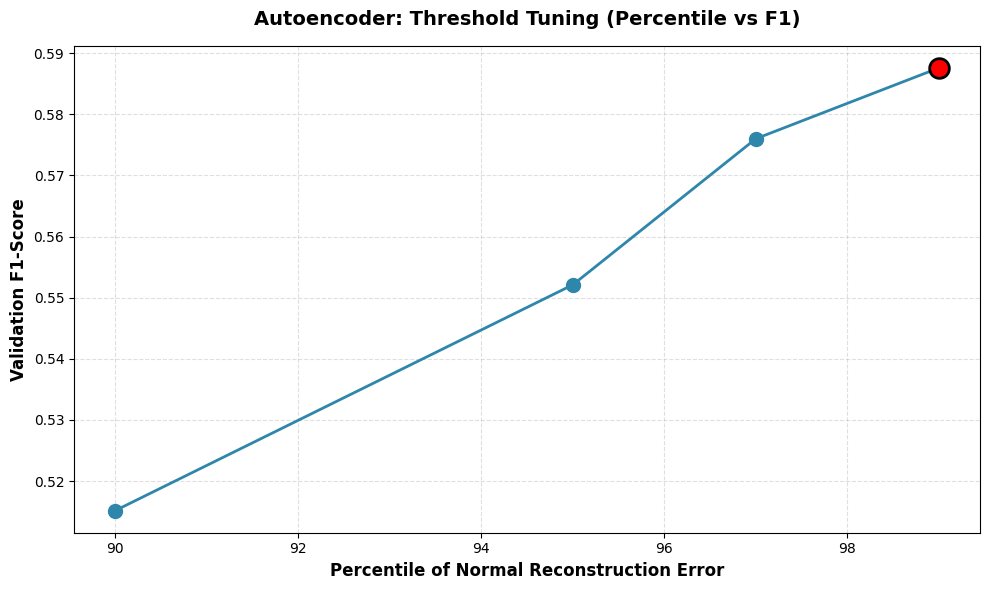

Saved: ae_threshold_tuning.png


In [ ]:
#SEVENTH PLOT (AE): Threshold Tuning for Autoencoder
percentiles_plot = [t[0] for t in threshold_f1_ae]
f1_ae_plot = [t[2] for t in threshold_f1_ae]

plt.figure(figsize=(10, 6))
plt.plot(percentiles_plot, f1_ae_plot, marker='o', markersize=10, linewidth=2, color='#2E86AB')
plt.xlabel('Percentile of Normal Reconstruction Error', fontsize=12, fontweight='bold')
plt.ylabel('Validation F1-Score', fontsize=12, fontweight='bold')
plt.title('Autoencoder: Threshold Tuning (Percentile vs F1)',
          fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.4)

# Mark best
best_idx_thresh = f1_ae_plot.index(max(f1_ae_plot))
plt.scatter(percentiles_plot[best_idx_thresh], f1_ae_plot[best_idx_thresh],
           color='red', s=200, zorder=5, edgecolors='black', linewidth=2)


plt.tight_layout()
plt.savefig('ae_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ae_threshold_tuning.png")


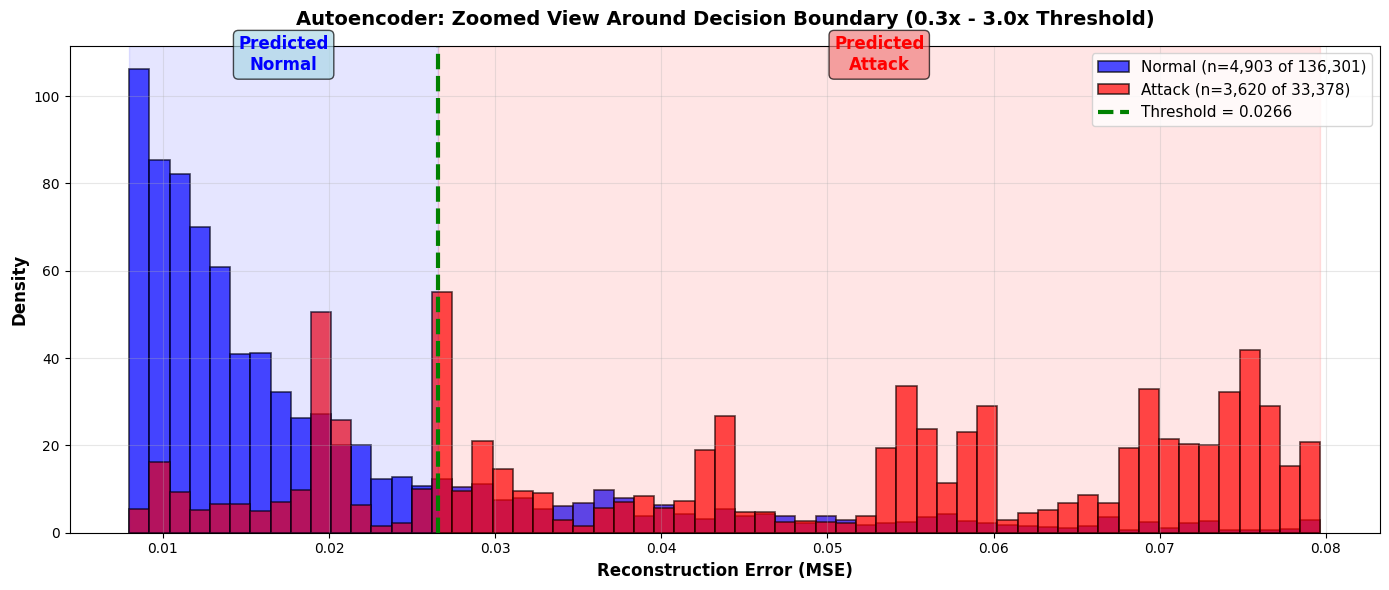

Saved: ae_reconstruction_zoomed.png


In [ ]:
# THIRD PLOT (AE): Zoomed-In View Around Threshold (Better Scaling)
test_errors_normal = reconstruction_errors_test[y_test == 0]
test_errors_attack = reconstruction_errors_test[y_test == 1]

plt.figure(figsize=(14, 6))

# Focus on critical region (0.5x to 3x threshold)
lower_bound = best_ae_threshold * 0.3
upper_bound = best_ae_threshold * 3.0

# Filter data to zoom region
normal_zoom = test_errors_normal[(test_errors_normal >= lower_bound) & (test_errors_normal <= upper_bound)]
attack_zoom = test_errors_attack[(test_errors_attack >= lower_bound) & (test_errors_attack <= upper_bound)]

# Create better bins for zoomed view
bins_zoom = np.linspace(lower_bound, upper_bound, 60)

plt.hist(normal_zoom, bins=bins_zoom, alpha=0.7,
         label=f'Normal (n={len(normal_zoom):,} of {len(test_errors_normal):,})',
         color='blue', edgecolor='black', density=True, linewidth=1.2)
plt.hist(attack_zoom, bins=bins_zoom, alpha=0.7,
         label=f'Attack (n={len(attack_zoom):,} of {len(test_errors_attack):,})',
         color='red', edgecolor='black', density=True, linewidth=1.2)
plt.axvline(best_ae_threshold, color='green', linestyle='--', linewidth=3,
           label=f'Threshold = {best_ae_threshold:.4f}')

plt.xlabel('Reconstruction Error (MSE)', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')
plt.title('Autoencoder: Zoomed View Around Decision Boundary (0.3x - 3.0x Threshold)',
          fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper right')
plt.grid(alpha=0.3)

# Add decision zones with shading
plt.axvspan(lower_bound, best_ae_threshold, alpha=0.1, color='blue', label='_')
plt.axvspan(best_ae_threshold, upper_bound, alpha=0.1, color='red', label='_')

plt.text(lower_bound + (best_ae_threshold - lower_bound)/2, plt.ylim()[1]*0.95,
         'Predicted\nNormal', ha='center', fontsize=12, fontweight='bold',
         color='blue', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
plt.text(best_ae_threshold + (upper_bound - best_ae_threshold)/2, plt.ylim()[1]*0.95,
         'Predicted\nAttack', ha='center', fontsize=12, fontweight='bold',
         color='red', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.savefig('ae_reconstruction_zoomed.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ae_reconstruction_zoomed.png")


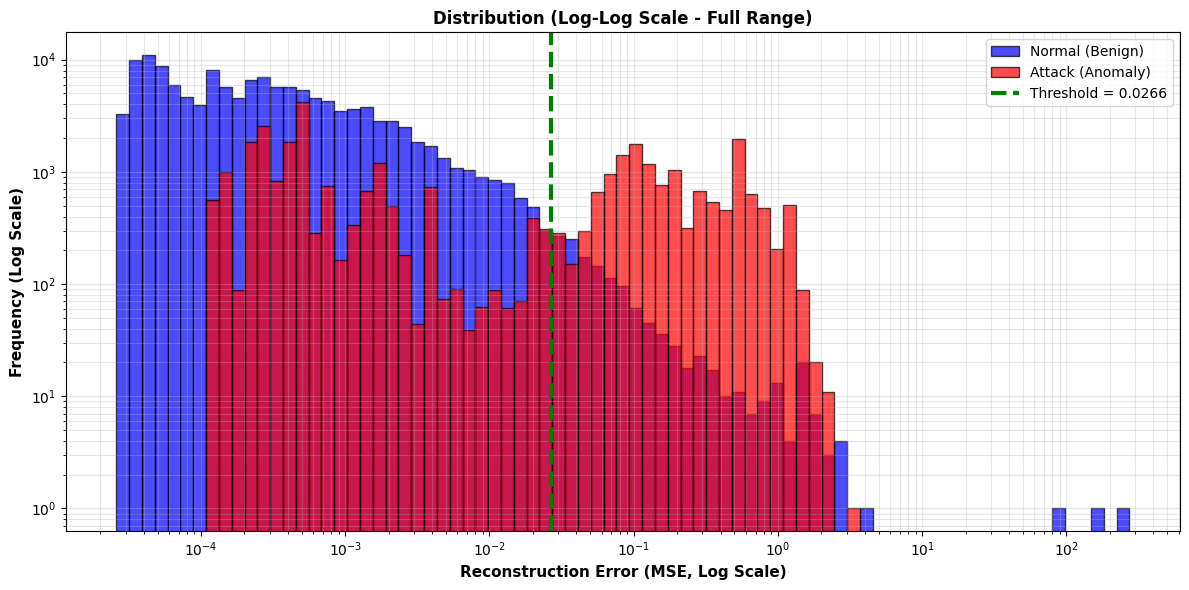

Saved: 'ae_log_scales.png


In [ ]:
#FORTH PLOT (AE): Log Scale Histogram (Better for Full Range)

fig, ax2 = plt.subplots(figsize=(12, 6))

# Use log-spaced bins for better visualization
bins_log = np.logspace(np.log10(max(reconstruction_errors_test.min(), 1e-8)),
                        np.log10(reconstruction_errors_test.max()), 80)

ax2.hist(test_errors_normal, bins=bins_log, alpha=0.7, label='Normal (Benign)',
         color='blue', edgecolor='black')
ax2.hist(test_errors_attack, bins=bins_log, alpha=0.7, label='Attack (Anomaly)',
         color='red', edgecolor='black')
ax2.axvline(best_ae_threshold, color='green', linestyle='--', linewidth=3,
           label=f'Threshold = {best_ae_threshold:.4f}')

ax2.set_xlabel('Reconstruction Error (MSE, Log Scale)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency (Log Scale)', fontsize=11, fontweight='bold')
ax2.set_title('Distribution (Log-Log Scale - Full Range)', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('ae_log_scales.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 'ae_log_scales.png")



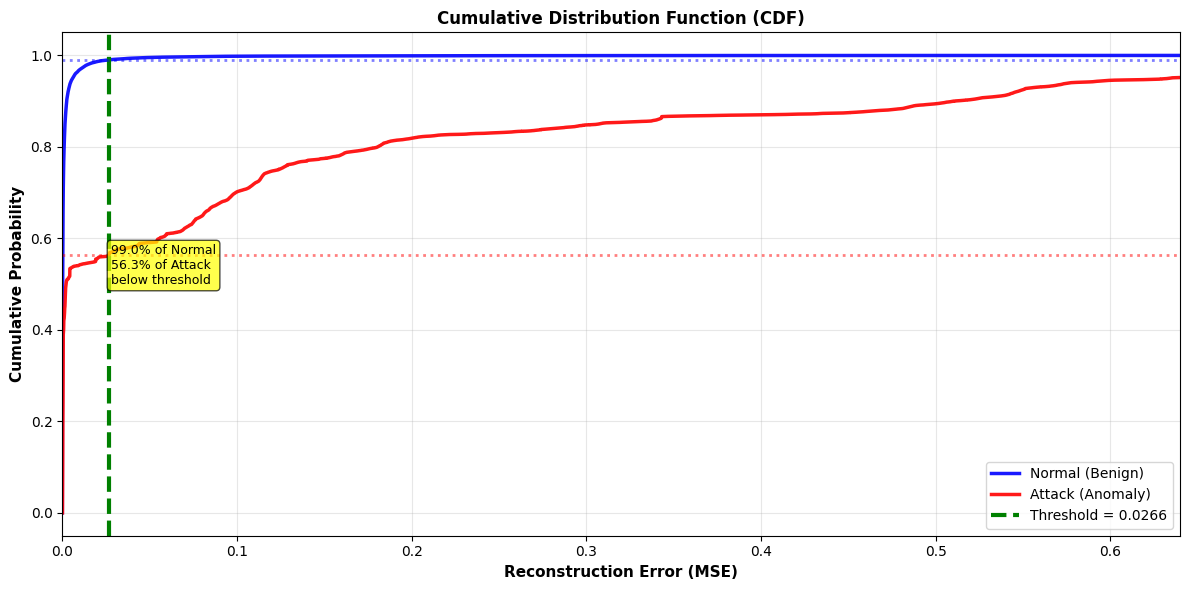

Saved: ae_reconstruction_error_analysis.png


In [ ]:
# FIFTH PLOT (AE): Cumulative Distribution Function (CDF)

fig, ax4 = plt.subplots(figsize=(12, 6))

# Sort data for CDF
sorted_normal = np.sort(test_errors_normal)
sorted_attack = np.sort(test_errors_attack)
# Define x_max so the plot stays focused on the relevant data range
x_max = np.percentile(reconstruction_errors_test, 99)

# Calculate CDF
cdf_normal = np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)
cdf_attack = np.arange(1, len(sorted_attack) + 1) / len(sorted_attack)

ax4.plot(sorted_normal, cdf_normal, color='blue', linewidth=2.5,
         label='Normal (Benign)', alpha=0.9)
ax4.plot(sorted_attack, cdf_attack, color='red', linewidth=2.5,
         label='Attack (Anomaly)', alpha=0.9)
ax4.axvline(best_ae_threshold, color='green', linestyle='--', linewidth=3,
           label=f'Threshold = {best_ae_threshold:.4f}')

# Add horizontal lines showing threshold performance
threshold_cdf_normal = np.searchsorted(sorted_normal, best_ae_threshold) / len(sorted_normal)
threshold_cdf_attack = np.searchsorted(sorted_attack, best_ae_threshold) / len(sorted_attack)

ax4.axhline(threshold_cdf_normal, color='blue', linestyle=':', linewidth=2, alpha=0.5)
ax4.axhline(threshold_cdf_attack, color='red', linestyle=':', linewidth=2, alpha=0.5)

ax4.set_xlabel('Reconstruction Error (MSE)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
ax4.set_title('Cumulative Distribution Function (CDF)', fontsize=12, fontweight='bold')
ax4.set_xlim(0, x_max)
ax4.legend(fontsize=10, loc='lower right')
ax4.grid(alpha=0.3)

# Add annotation
ax4.text(best_ae_threshold * 1.05, 0.5,
         f'{threshold_cdf_normal*100:.1f}% of Normal\n{threshold_cdf_attack*100:.1f}% of Attack\nbelow threshold',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('ae_reconstruction_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ae_reconstruction_error_analysis.png")



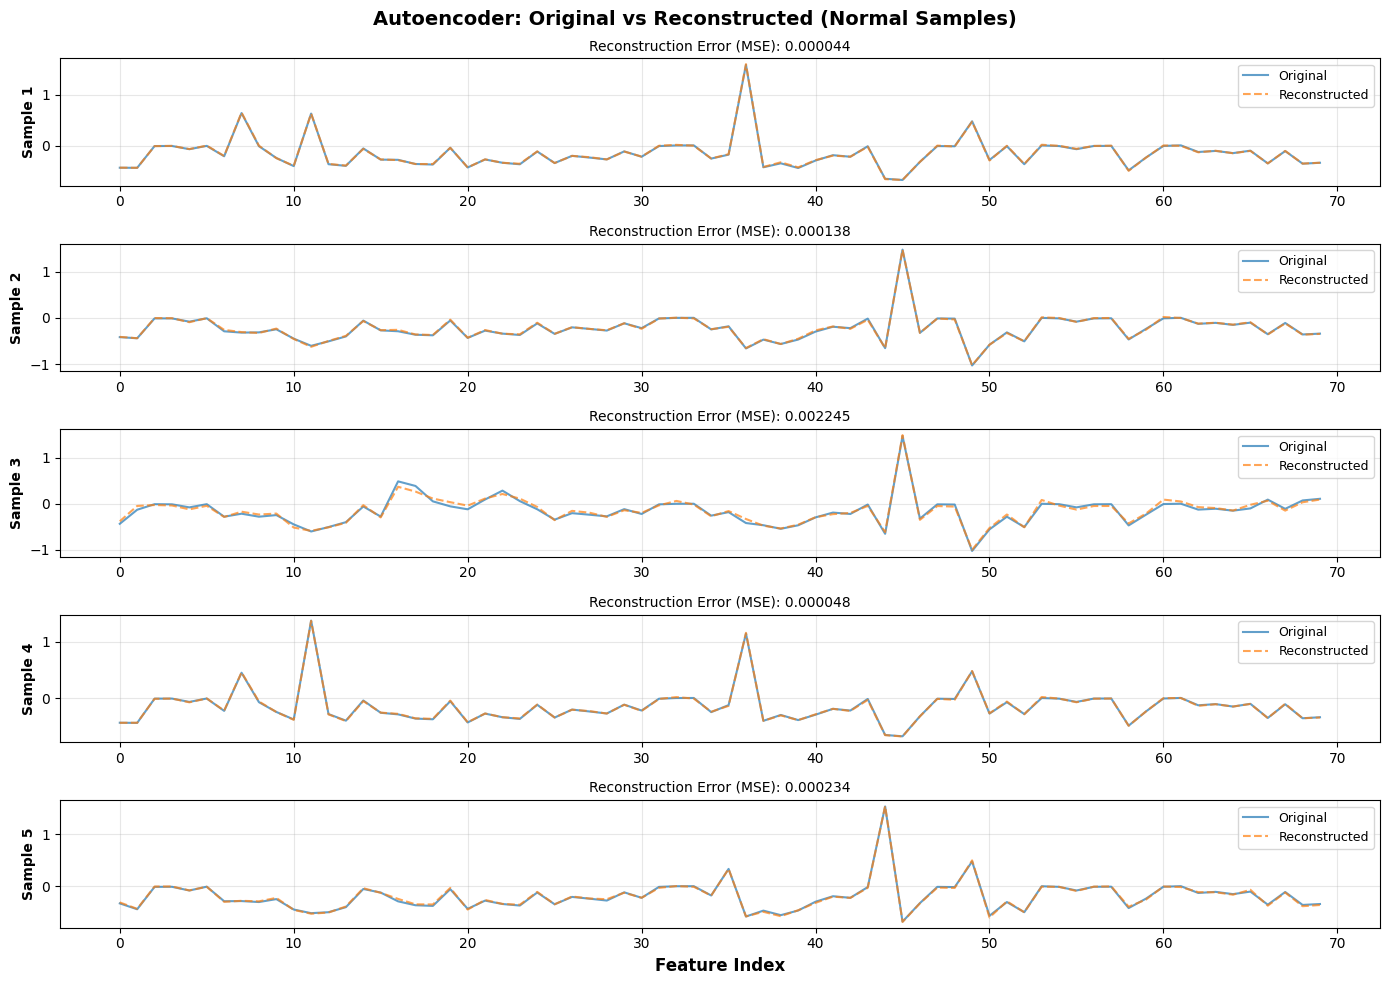

Saved: ae_sample_reconstructions.png


In [ ]:
#SIXTH PLOT (AE): Sample Reconstructions (Visual)
# Show original vs reconstructed for a few samples
n_samples = 5
sample_indices = np.random.choice(len(X_test_normal := X_test[y_test == 0]), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 1, figsize=(14, 10))
fig.suptitle('Autoencoder: Original vs Reconstructed (Normal Samples)',
             fontsize=14, fontweight='bold')

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        sample_tensor = torch.FloatTensor(X_test[idx:idx+1]).to(device)
        reconstructed = final_model(sample_tensor).cpu().numpy()[0]

        # Plot comparison
        axes[i].plot(X_test[idx], label='Original', alpha=0.7, linewidth=1.5)
        axes[i].plot(reconstructed, label='Reconstructed', alpha=0.7, linewidth=1.5, linestyle='--')
        axes[i].set_ylabel(f'Sample {i+1}', fontsize=10, fontweight='bold')
        axes[i].legend(loc='upper right', fontsize=9)
        axes[i].grid(alpha=0.3)

        error = np.mean(np.square(X_test[idx] - reconstructed))
        axes[i].set_title(f'Reconstruction Error (MSE): {error:.6f}', fontsize=10)

axes[-1].set_xlabel('Feature Index', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ae_sample_reconstructions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ae_sample_reconstructions.png")

In [ ]:
all_results

[{'Model': 'Autoencoder',
  'Accuracy': 0.8810518685282209,
  'Precision': 0.9121119370354176,
  'Recall': 0.43747378512792856,
  'F1-Score': 0.5913297021483386,
  'Training Time (s)': 307.2105071544647,
  'Prediction Time (s)': 0.5339498519897461}]

In [ ]:
#Comment out if want to load the AE results to all_resuts list without rerunning everything
#ae_saved_metrics = {'Model': 'Autoencoder',
  #'Accuracy': 0.8810518685282209,
  #'Precision': 0.9121119370354176,
  #'Recall': 0.43747378512792856,
  #'F1-Score': 0.5913297021483386,
  #'Training Time (s)': 307.2105071544647,
  #'Prediction Time (s)': 0.5339498519897461}

#all_results.append(ae_saved_metrics)

#Final comparison


In [ ]:
all_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9177211086816872,
  'Precision': 0.7169157897088724,
  'Recall': 0.9613218287494757,
  'F1-Score': 0.8213220707749408,
  'Training Time (s)': 72.36719608306885,
  'Prediction Time (s)': 0.04415488243103027},
 {'Model': 'Random Forest',
  'Accuracy': 0.9987093276127276,
  'Precision': 0.9956946811373217,
  'Recall': 0.9977530109653064,
  'F1-Score': 0.9967227833894501,
  'Training Time (s)': 205.06956362724304,
  'Prediction Time (s)': 4.733032464981079},
 {'Model': 'Isolation Forest',
  'Accuracy': 0.8579671025878276,
  'Precision': 0.7251941747572815,
  'Recall': 0.44757025585715143,
  'F1-Score': 0.5535218051798881,
  'Training Time (s)': 22.16296100616455,
  'Prediction Time (s)': 5.954294681549072},
 {'Model': 'Autoencoder',
  'Accuracy': 0.8810518685282209,
  'Precision': 0.9121119370354176,
  'Recall': 0.43747378512792856,
  'F1-Score': 0.5913297021483386,
  'Training Time (s)': 307.2105071544647,
  'Prediction Time (s)': 0.533949

FINAL MODEL COMPARISON

              Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)  Prediction Time (s)
Logistic Regression  0.917721   0.716916 0.961322  0.821322          72.367196             0.044155
      Random Forest  0.998709   0.995695 0.997753  0.996723         205.069564             4.733032
   Isolation Forest  0.857967   0.725194 0.447570  0.553522          22.162961             5.954295
        Autoencoder  0.881052   0.912112 0.437474  0.591330         307.210507             0.533950


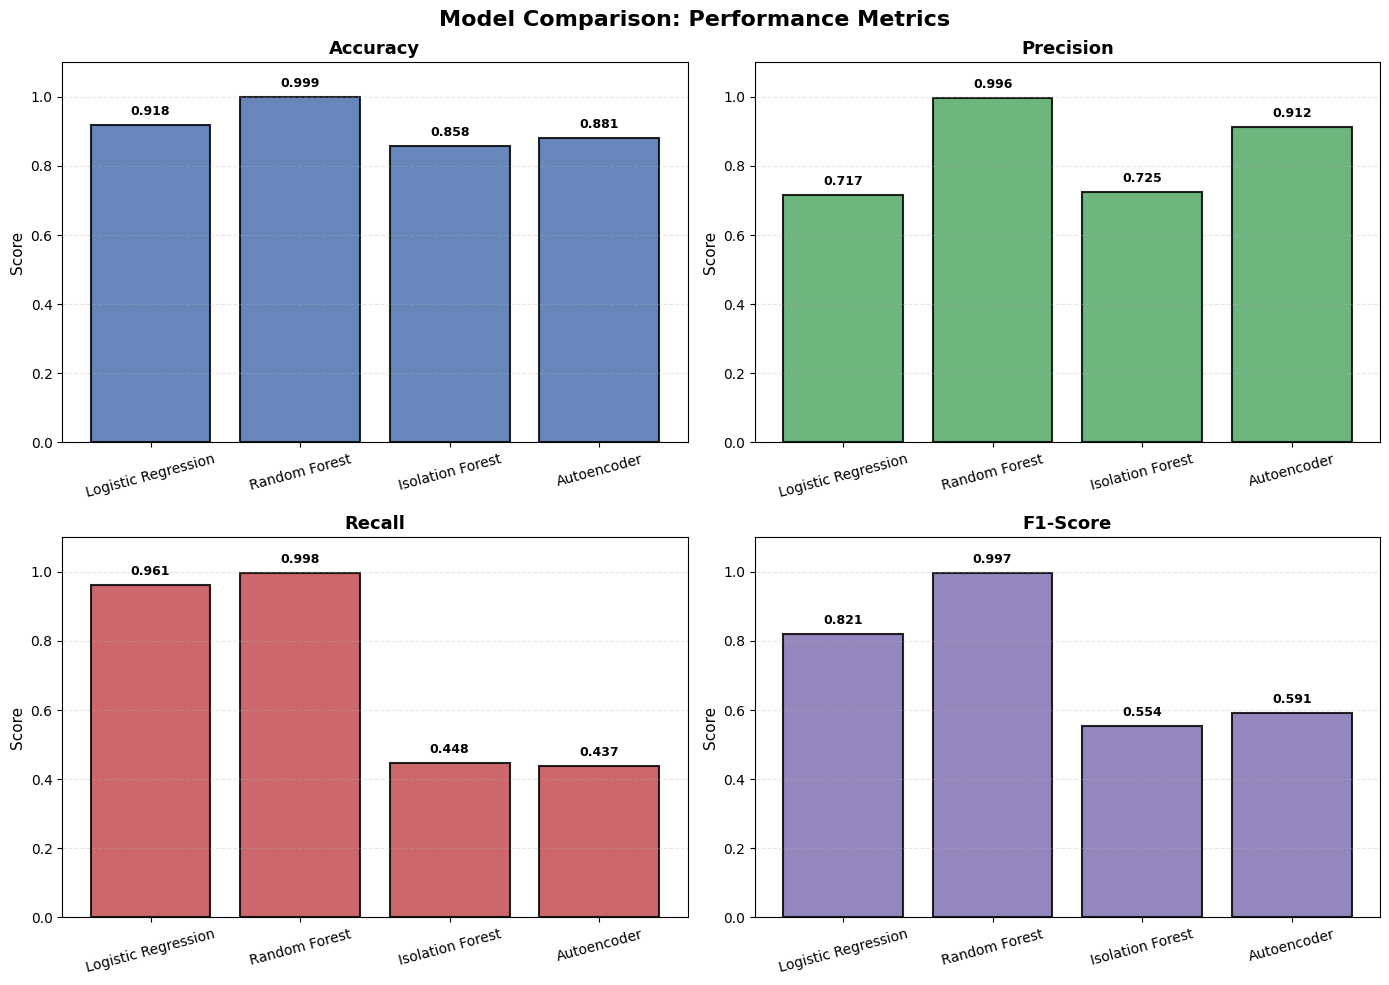

Saved: all_models_comparison.png


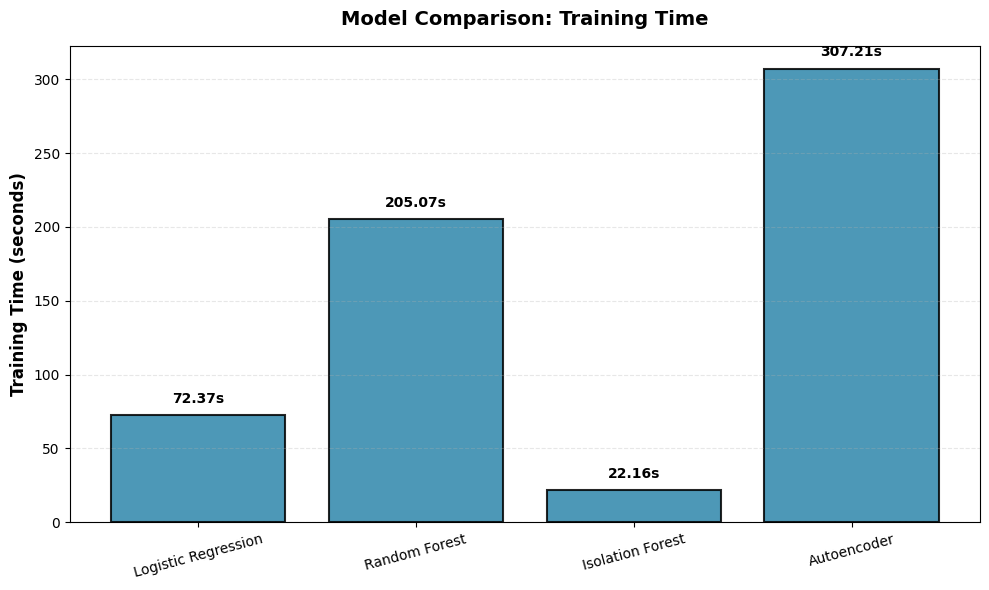

Saved: training_time_comparison.png

BEST PERFORMING MODELS BY METRIC
Accuracy    : Random Forest             (0.9987)
Precision   : Random Forest             (0.9957)
Recall      : Random Forest             (0.9978)
F1-Score    : Random Forest             (0.9967)

ANALYSIS COMPLETE - ALL PLOTS SAVED


In [ ]:
# FINAL COMPARISON
print("FINAL MODEL COMPARISON")

results_df = pd.DataFrame(all_results)
print("\n" + results_df.to_string(index=False))

# ENHANCED PLOT: Model Comparison - All Metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison: Performance Metrics', fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_comp = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics_to_plot)):
    values = results_df[metric].values
    models = results_df['Model'].values

    bars = ax.bar(models, values, color=colors_comp[idx], edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.set_ylim(0, 1.1)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: all_models_comparison.png")

# PLOT: Training Time Comparison
plt.figure(figsize=(10, 6))
models = results_df['Model'].values
training_times = results_df['Training Time (s)'].values

bars = plt.bar(models, training_times, color='#2E86AB', edgecolor='black', linewidth=1.5, alpha=0.85)
plt.ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
plt.title('Model Comparison: Training Time', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(training_times)*0.02,
             f'{height:.2f}s', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_time_comparison.png")

# Best models summary
print("\n" + "="*80)
print("BEST PERFORMING MODELS BY METRIC")
print("="*80)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_idx = results_df[metric].idxmax()
    print(f"{metric:12s}: {results_df.loc[best_idx, 'Model']:25s} ({results_df.loc[best_idx, metric]:.4f})")

print("\n" + "="*80)
print("ANALYSIS COMPLETE - ALL PLOTS SAVED")
print("="*80)